## 1. Import Required Libraries
We begin by importing `numpy` for linear algebra computation, `pandas` for handling the loaded datasheet, and `matplotlib` for generating the decision spaces visually.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load & Explore the Dataset
Here, we ingest the `ushape.csv` file. This dataset contains points logically distributed in a "U-Shape", meaning typical linear classifiers (like basic Logistic Regression) will fail.

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


## 3. Visualize the Data
Let's see what the classes look like. We plot X and Y dimensions and color-code the dots based on their target class logic to highlight the non-linear separation boundary we need to learn.

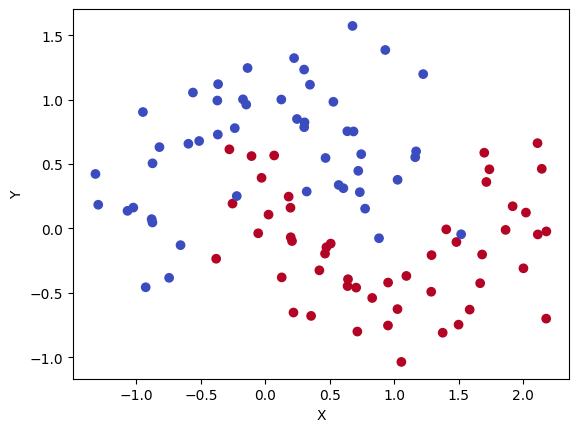

In [4]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df.iloc[:, 2], cmap='coolwarm')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

## 4. Data Preprocessing (Separating Features)
We need to split our Pandas DataFrame into input dimensions ($X_1$, $X_2$) and the actual target truth variable ($y$). `iloc[:, 0:2]` selects our dimensions, and `iloc[:, -1]` strips away the final target class array.

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

## 5. Building the Model Architecture
We are constructing a deep Artificial Neural Network using Keras.
- **Architecture:** 4 hidden layers, each initialized with 10 units utilizing the `ReLU` activation function (which combats vanishing gradients).
- **Out Layer:** 1 unit using `Sigmoid` activation (rendering binary classifications as probabilities between 0 and 1).

In [7]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.16977568, -0.23587884, -0.62184817,  1.6553153 , -1.9546665 ,
          0.75673217,  1.3691953 , -0.45701337,  0.45565963,  1.7742981 ],
        [ 1.7582587 , -1.7159423 ,  1.5300326 ,  1.1343659 ,  0.23984468,
         -1.6718194 ,  0.68411225,  0.17354167, -2.1910396 ,  1.0575291 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.27964392,  0.36658576, -0.11767849, -0.54075104,  0.4341229 ,
          0.01311396,  0.20128596, -0.06756815,  0.50934106,  0.36332843],
        [-0.45018497, -0.05261304,  0.13413404, -0.4131141 , -0.18557456,
          0.16035873, -0.3610074 ,  0.5679493 ,  0.6299768 , -0.12165482],
        [ 0.50464827,  0.10162423, -0.9217928 , -0.6220852 , -0.3430467 ,
         -0.2926633 ,  0.6224534 , -0.6206774 , -0.2043579 , -0.01941229],
        [-0.37668005, -0.6984711 ,  0.8670875 , -0.26450685,  0.32417983,
          0.47013536,  0.08046217, -0.07528806,  0.07335946,  0.49961454],
        [-0.40252

In [9]:
initial_weights = model.get_weights()

## 6. Mathematical Weight Initialization
Here we are overriding default Initializations to manually demonstrate Variance Scaling.
Using normally distributed random numbers `np.random.randn()`, we scale them by $\sqrt{\frac{1}{\text{fan\_in}}}$ where `fan_in` represents the nodes from the previous layer. This prevents inputs from vanishing or exploding as they propagate deeply into the network.
*Note: We also correctly initialize biases as arrays of zeros.*

In [10]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [11]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[ 0.42900074,  0.815572  ,  0.6388259 ,  0.7068037 , -0.9151288 ,
         -0.34944794,  0.26193598, -0.16392842, -0.3310982 , -0.8475045 ],
        [ 0.07216637,  0.15272927, -0.17301929, -0.9172083 , -0.9721148 ,
         -1.2356887 , -0.04279216, -1.0555813 ,  0.7444482 , -0.39147082]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.02170862,  0.18898185,  0.10573446, -0.7518257 ,  0.07730278,
         -0.11836608,  0.18679069, -0.06280321, -0.17511053,  0.19984588],
        [-0.05757519,  0.24327025, -0.6170295 ,  0.10782681,  0.05622557,
          0.28626356, -0.14278412, -0.08354349,  0.01920275, -0.24184483],
        [-0.5176758 , -0.00785331, -0.361457  , -0.07624372, -0.3608648 ,
          0.07375487,  0.06749129,  0.6288144 ,  0.33395562,  0.15722398],
        [ 0.20473151, -0.09562267,  0.35755858,  0.09942078, -0.18881465,
         -0.11973354,  0.03460233, -0.08152749,  0.9995774 , -0.3682792 ],
        [ 0.46965

In [13]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

## 7. Model Training & Evaluation
We compile the model specifying `adam` as our optimizer and `binary_crossentropy` as our loss evaluator. We'll run the training for 100 epochs, withholding 20% of the dataset for validation bounding to watch out for overfitting.

In [14]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.7468 - loss: 0.6769 - val_accuracy: 0.8000 - val_loss: 0.6678
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7848 - loss: 0.6721 - val_accuracy: 0.7500 - val_loss: 0.6629
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7848 - loss: 0.6667 - val_accuracy: 0.8000 - val_loss: 0.6580
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7848 - loss: 0.6618 - val_accuracy: 0.8000 - val_loss: 0.6532
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7848 - loss: 0.6567 - val_accuracy: 0.8000 - val_loss: 0.6481
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7848 - loss: 0.6520 - val_accuracy: 0.8000 - val_loss: 0.6428
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7848 - loss: 0.6465 - val_accuracy: 0.8000 - val_loss: 0.6373
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7848 - loss: 0.6410 - val_accuracy: 0.8000 - val_loss

In [15]:
model.get_weights()

[array([[ 0.40219325,  1.0321215 ,  0.71332896,  0.7020127 , -0.86707777,
         -0.48593676,  0.29092258, -0.15722181, -0.26425123, -1.1100764 ],
        [ 0.23404755,  0.32005945, -0.31336087, -1.0394169 , -0.8572553 ,
         -1.0927174 ,  0.04825589, -1.2546535 ,  0.94784236, -0.25104484]],
       dtype=float32),
 array([-0.03297187,  0.11308634,  0.11688174, -0.10908851,  0.02270447,
        -0.14040776,  0.05681689,  0.17003065,  0.09602346, -0.03691441],
       dtype=float32),
 array([[ 1.29235074e-01,  2.87890941e-01,  1.47671595e-01,
         -6.73618674e-01,  2.53057510e-01,  1.08743191e-01,
          3.40347439e-01,  5.85812936e-03, -1.85569286e-01,
          3.06253374e-01],
        [ 9.64341164e-02,  3.34314197e-01, -7.03158498e-01,
          2.09108874e-01,  2.30848506e-01,  4.91672784e-01,
         -1.53851826e-02, -3.01432749e-03,  5.33444015e-03,
         -1.41594872e-01],
        [-3.56133640e-01,  8.39793980e-02, -4.09309357e-01,
          4.76207286e-02, -2.06122

## 8. Decision Boundary Visualization
Finally, let's evaluate how our neural network generalizes the decision space. We utilize the `mlxtend` library to draw regional decision contours atop our original scatterplot. If done correctly, it should accurately trace the U-Shape!

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

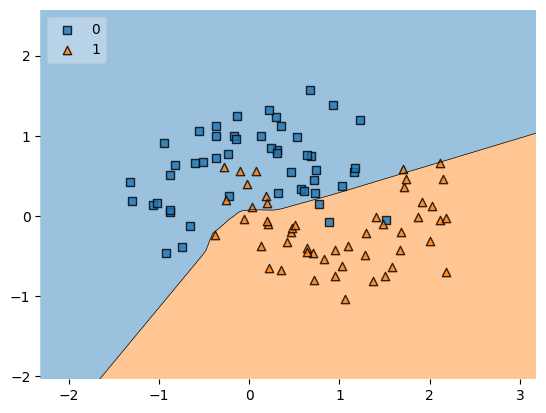

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.020619994027183428)

In [18]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.02177946578216443)